In [1]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

### Step 1: Create the ordered expression profile

In [ ]:
seed = 110
rng = np.random.default_rng(seed)

n_cells = 1000
n_genes = 2000

# Gene 1 = lowest expression, gene 2000 = highest expression
gene_means = np.linspace(0.1, 100, n_genes)

# Randomize cell-level counts around the same gene means
X = rng.poisson(gene_means, size=(n_cells, n_genes))

obs = pd.DataFrame(
    {"group": ["celltype1"] * n_cells},
    index=[f"cell_{i}" for i in range(n_cells)]
)

var = pd.DataFrame(
    {"expression_rank": np.arange(1, n_genes + 1),
     "true_mean": gene_means},
    index=[f"gene_{i}" for i in range(n_genes)]
)

adata = ad.AnnData(
    X=sparse.csr_matrix(X),
    obs=obs,
    var=var
)

adata.write_h5ad("../outputs/Methods_Comparison/ordered_2000_genes.h5ad")

### Fraction of zeros in the generated dataset

In [ ]:
n_entries = adata.n_obs * adata.n_vars
n_zeros = n_entries - adata.X.count_nonzero()
zero_fraction = n_zeros / n_entries

print(f"Fraction of zeros: {zero_fraction:.2%} ({n_zeros:,} / {n_entries:,} entries)")

Fraction of zeros: 0.93% (18,634 / 2,000,000 entries)


### Visualize the observed mean expression

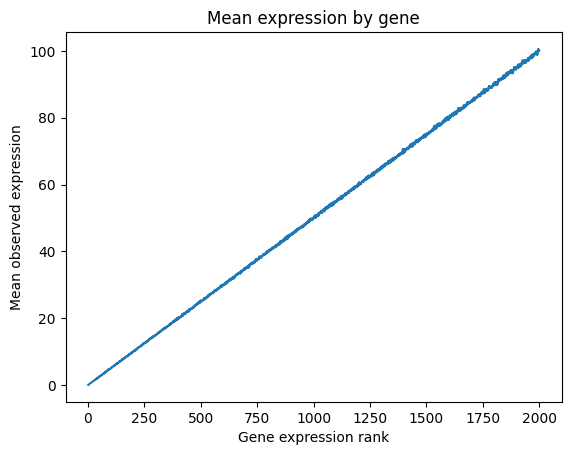

In [5]:
gene_means_observed = np.asarray(adata.X.mean(axis=0)).ravel()

plt.plot(adata.var["expression_rank"], gene_means_observed)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

### Visualize individual cell counts

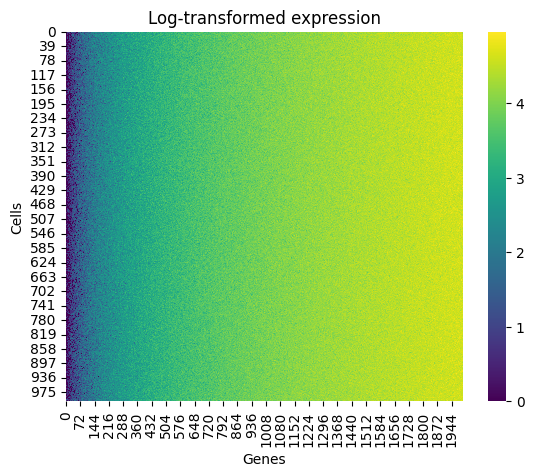

In [ ]:
counts = adata.X.toarray()

sns.heatmap(np.log1p(counts), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

### Step 2: Run every dropout method
Use scripts/submit_generate_zeros.sh

For the ZINB-WaVE method, ensure that the transposed count matrix is converted to the sparse matrix format expected by zinbFit():

X_gc_counts <- Matrix::Matrix(as.matrix(t(X)),sparse = TRUE)

X_gc_counts <- methods::as(X_gc_counts, "dgCMatrix")

Our ordered dataset is read as a dgRMatrix, whereas zinbFit() requires a dgCMatrix. The other dropout methods do not require this conversion.

### Step 3: Investigate dropout

In [2]:
adata = ad.read_h5ad("../outputs/Methods_Comparison/ordered_2000_genes.h5ad")

#### Calculate which genes were dropped

In [3]:
true = ad.read_h5ad("../outputs/Methods_Comparison/ordered_2000_genes.h5ad")
true_X = true.X.toarray() if hasattr(true.X, "toarray") else np.asarray(true.X)

records = []

for path in glob.glob("../outputs/Methods_Comparison/50p/*.h5ad"):
    observed = ad.read_h5ad(path)
    obs_X = observed.X.toarray() if hasattr(observed.X, "toarray") else np.asarray(observed.X)

    newly_dropped = (true_X > 0) & (obs_X == 0)

    dropout_fraction_by_gene = newly_dropped.mean(axis=0)

    records.append(pd.DataFrame({
        "method_file": os.path.basename(path),
        "gene_rank": np.arange(1, 2001),
        "true_mean": np.asarray(true.var["true_mean"]),
        "dropout_fraction": dropout_fraction_by_gene
    }))

results = pd.concat(records, ignore_index=True)
results.to_csv("../outputs/Methods_Comparison/50p/gene_dropout_results.csv", index=False)

#### Visualize

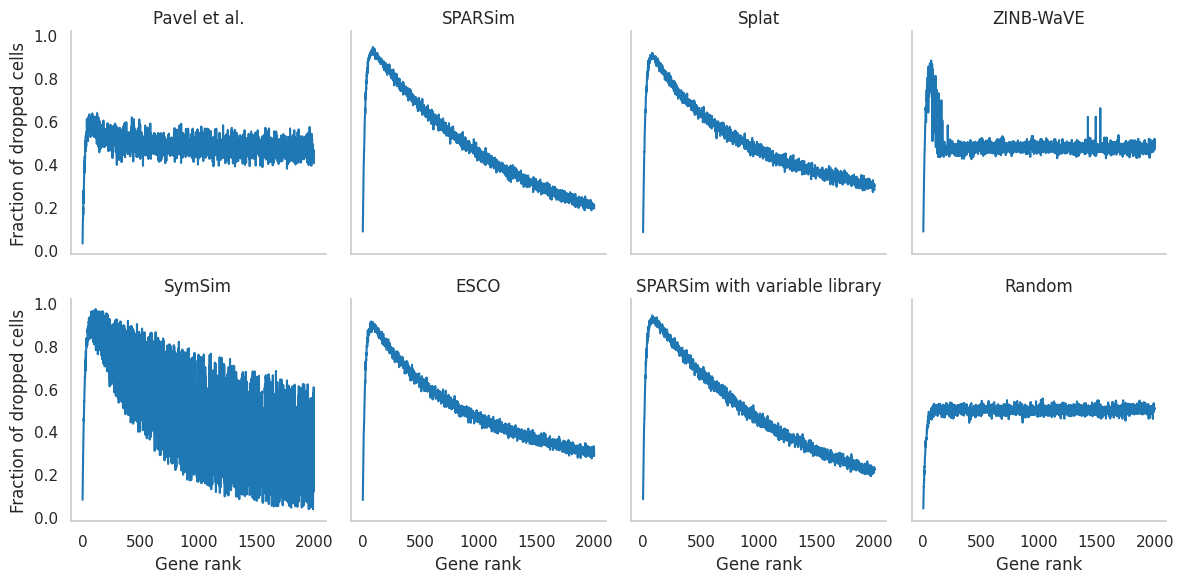

In [4]:
def get_method(filename):
    name = os.path.basename(filename).lower()

    if name.startswith("dropout_"):
        return "pavel"
    elif name.startswith("sparsimvarlib_"):
        return "sparsimvarlib"
    elif name.startswith("sparsim_"):
        return "sparsim"
    elif name.startswith("splat_"):
        return "splat"
    elif name.startswith("zinbwave_"):
        return "zinbwave"
    elif name.startswith("symsim_"):
        return "symsim"
    elif name.startswith("esco_"):
        return "esco"
    elif name.startswith("random_"):
        return "random"
    else:
        return "unknown"

results["method_key"] = results["method_file"].apply(get_method)

# Map method names to names suitable for the figure
method_labels = {
    "pavel": "Pavel et al.",
    "sparsim": "SPARSim",
    "sparsimvarlib": "SPARSim with variable library",
    "splat": "Splat",
    "zinbwave": "ZINB-WaVE",
    "symsim": "SymSim",
    "esco": "ESCO",
    "random": "Random",
}

results["method"] = results["method_key"].map(method_labels)

# Order methods for plotting
method_order = [
    "Pavel et al.",
    "SPARSim",
    "Splat",
    "ZINB-WaVE",
    "SymSim",
    "ESCO",
    "SPARSim with variable library",
    "Random",
]

results["method"] = pd.Categorical(
    results["method"],
    categories=method_order,
    ordered=True
)

results = results.sort_values("method")

sns.set_theme(style="whitegrid")

g = sns.FacetGrid(
    results,
    col="method",
    col_wrap=4,
    height=3,
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="gene_rank",
    y="dropout_fraction",
    color="#1F77B4",
    errorbar=None
)

for ax in g.axes.flat:
    ax.grid(False)

g.set_axis_labels(
    "Gene rank",
    "Fraction of dropped cells"
)

g.set_titles("{col_name}")
plt.tight_layout()
plt.savefig(
    "../outputs/Methods_Comparison/50p/dropout_by_expression_rank.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

#### Investigate each dropout method separately

##### Pavel et al.

In [5]:
pavel_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "dropout_observed_counts_Other_Other_2000genes_0p90rate_49p67pct0_110seed.h5ad"
)

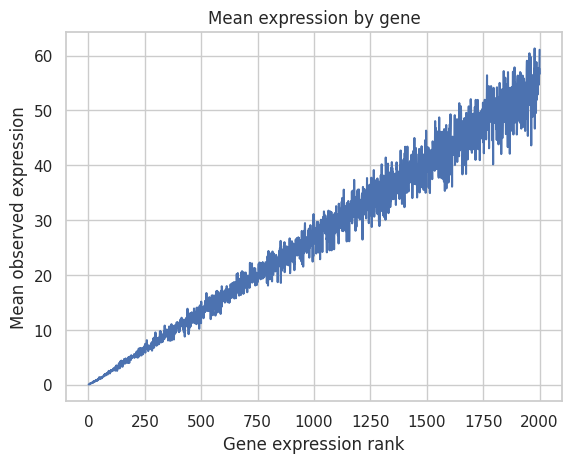

In [6]:
gene_means_observed_pavel = np.asarray(pavel_adata.X.mean(axis=0)).ravel()

plt.plot(pavel_adata.var["expression_rank"], gene_means_observed_pavel)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

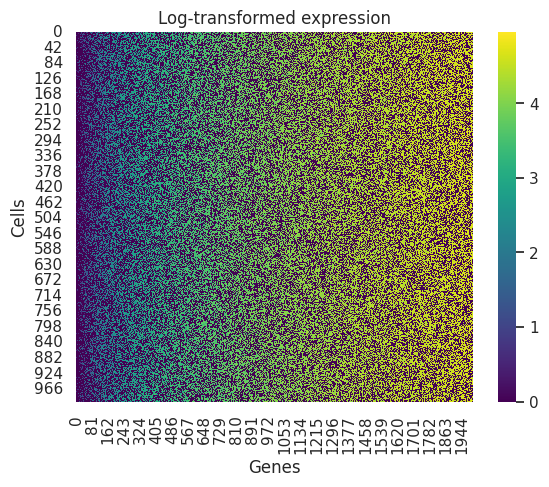

In [7]:
counts_pavel = pavel_adata.X.toarray()

sns.heatmap(np.log1p(counts_pavel), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### SPARSim

In [8]:
sparsim_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "sparsim_observed_counts_Other_Other_2000genes_1600library_49p83pct0_110seed.h5ad"
)

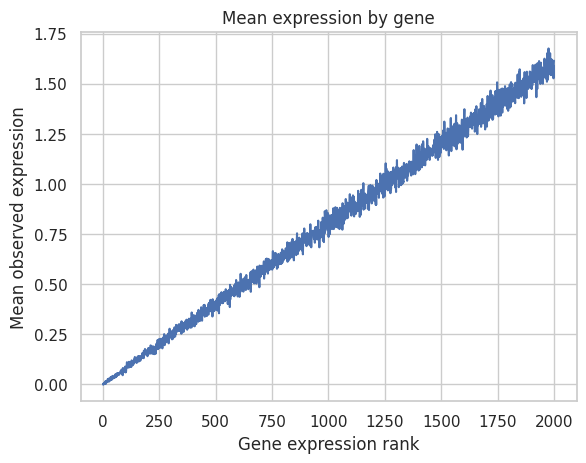

In [9]:
gene_means_observed_sparsim = np.asarray(sparsim_adata.X.mean(axis=0)).ravel()

plt.plot(sparsim_adata.var["expression_rank"], gene_means_observed_sparsim)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

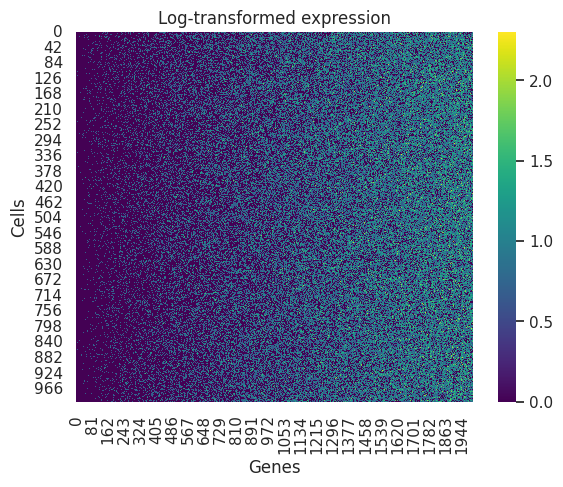

In [10]:
counts_sparsim = sparsim_adata.X.toarray()

sns.heatmap(np.log1p(counts_sparsim), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### Splat

In [11]:
splat_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "splat_observed_counts_Other_Other_2000genes_3p75mid_m1p00shape_51p63pct0_110seed.h5ad"
)

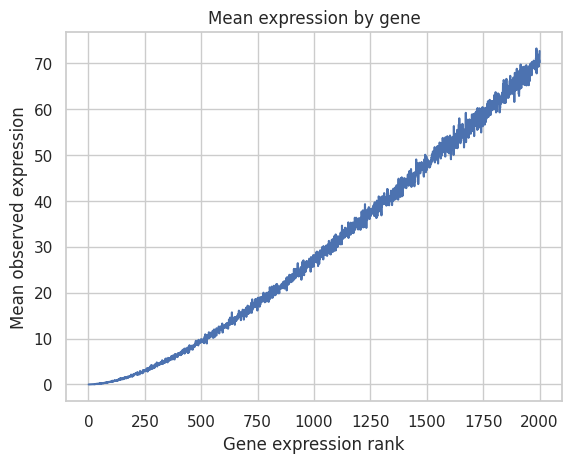

In [12]:
gene_means_observed_splat = np.asarray(splat_adata.X.mean(axis=0)).ravel()

plt.plot(splat_adata.var["expression_rank"], gene_means_observed_splat)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

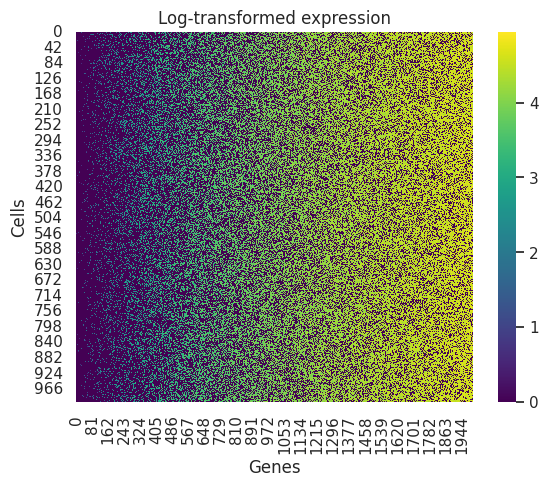

In [13]:
counts_splat = splat_adata.X.toarray()

sns.heatmap(np.log1p(counts_splat), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### ZINB-WaVE

In [14]:
zinbwave_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "zinbwave_observed_counts_Other_Other_2000genes_6p9alpha0_49p68pct0_110seed.h5ad"
)

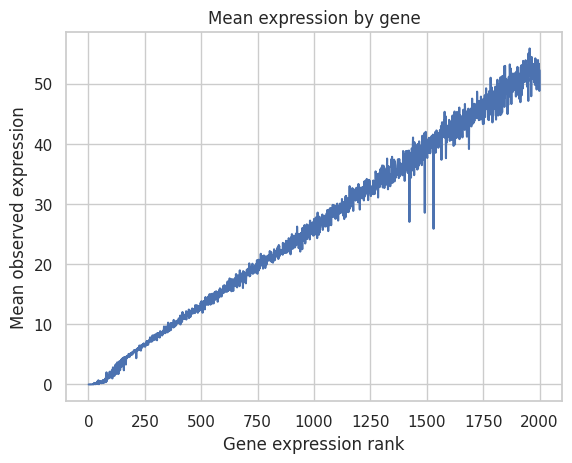

In [15]:
gene_means_observed_zinbwave = np.asarray(zinbwave_adata.X.mean(axis=0)).ravel()

plt.plot(zinbwave_adata.var["expression_rank"], gene_means_observed_zinbwave)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

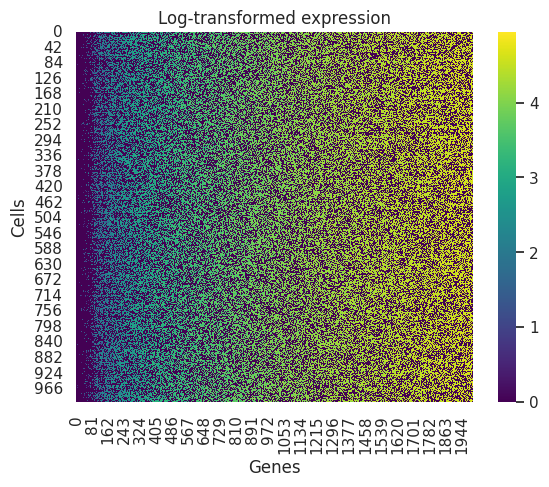

In [16]:
counts_zinbwave = zinbwave_adata.X.toarray()

sns.heatmap(np.log1p(counts_zinbwave), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### SymSim

In [17]:
symsim_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "symsim_observed_counts_Other_Other_2000genes_2400depth_51p00pct0_110seed.h5ad"
)

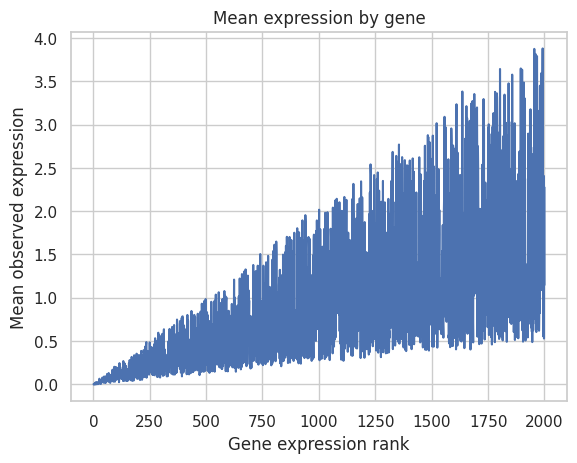

In [18]:
gene_means_observed_symsim = np.asarray(symsim_adata.X.mean(axis=0)).ravel()

plt.plot(symsim_adata.var["expression_rank"], gene_means_observed_symsim)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

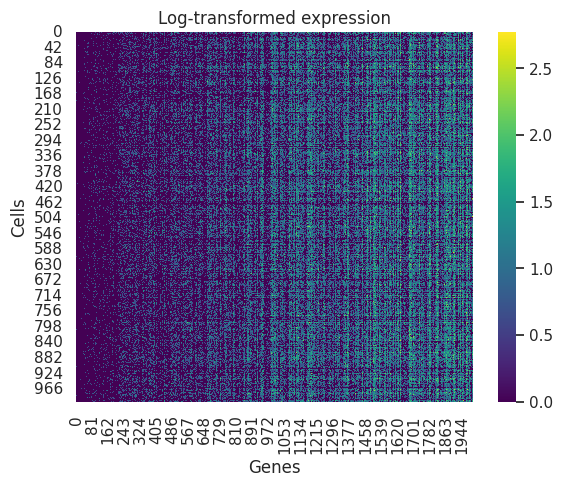

In [19]:
counts_symsim = symsim_adata.X.toarray()

sns.heatmap(np.log1p(counts_symsim), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### ESCO

In [20]:
esco_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "esco_observed_counts_Other_Other_2000genes_3p75mid_m1p00shape_51p60pct0_110seed.h5ad"
)

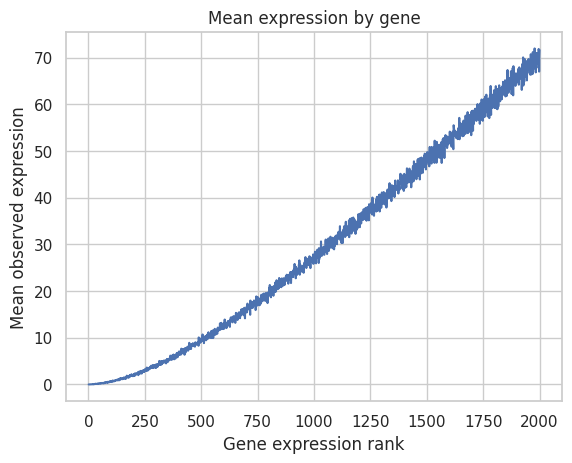

In [21]:
gene_means_observed_esco = np.asarray(esco_adata.X.mean(axis=0)).ravel()

plt.plot(esco_adata.var["expression_rank"], gene_means_observed_esco)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

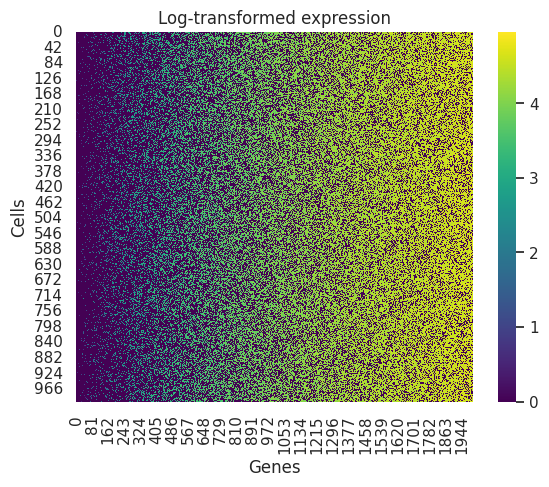

In [22]:
counts_esco = esco_adata.X.toarray()

sns.heatmap(np.log1p(counts_esco), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### SPARSim variable library

In [23]:
sparsimvarlib_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "sparsimvarlib_observed_counts_Other_Other_2000genes_1600meanlibrary_102400varlibrary_50p51pct0_110seed.h5ad"
)

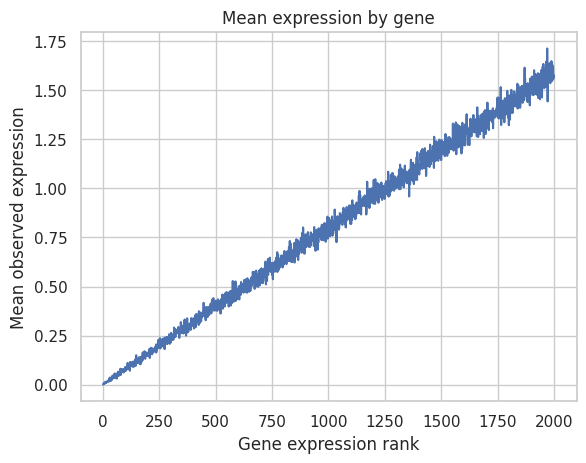

In [24]:
gene_means_observed_sparsimvarlib = np.asarray(sparsimvarlib_adata.X.mean(axis=0)).ravel()

plt.plot(sparsimvarlib_adata.var["expression_rank"], gene_means_observed_sparsimvarlib)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

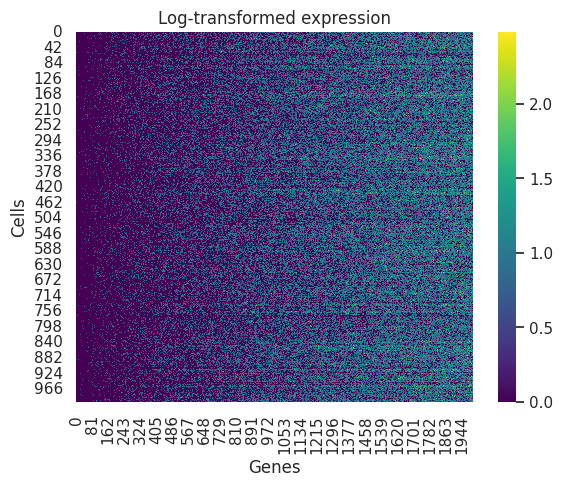

In [25]:
counts_sparsimvarlib = sparsimvarlib_adata.X.toarray()

sns.heatmap(np.log1p(counts_sparsimvarlib), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### Random

In [26]:
random_adata = ad.read_h5ad(
    "../outputs/Methods_Comparison/50p/"
    "random_observed_counts_Other_Other_2000genes_0p50prop_50p47pct0_110seed.h5ad"
)

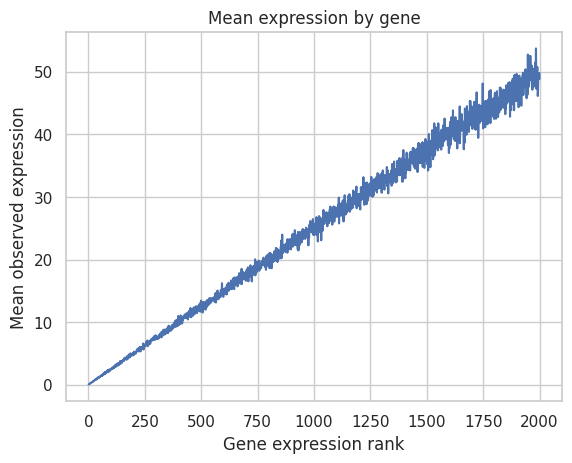

In [27]:
gene_means_observed_random = np.asarray(random_adata.X.mean(axis=0)).ravel()

plt.plot(random_adata.var["expression_rank"], gene_means_observed_random)
plt.xlabel("Gene expression rank")
plt.ylabel("Mean observed expression")
plt.title("Mean expression by gene")
plt.show()

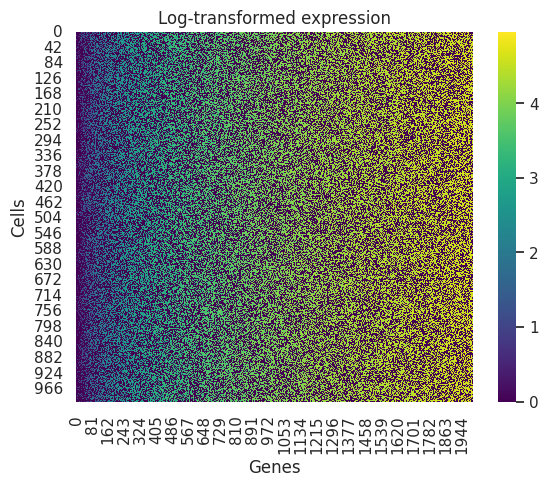

In [28]:
counts_random = random_adata.X.toarray()

sns.heatmap(np.log1p(counts_random), cmap="viridis")
plt.xlabel("Genes")
plt.ylabel("Cells")
plt.title("Log-transformed expression")
plt.show()

##### Create a figure comparing all the methods

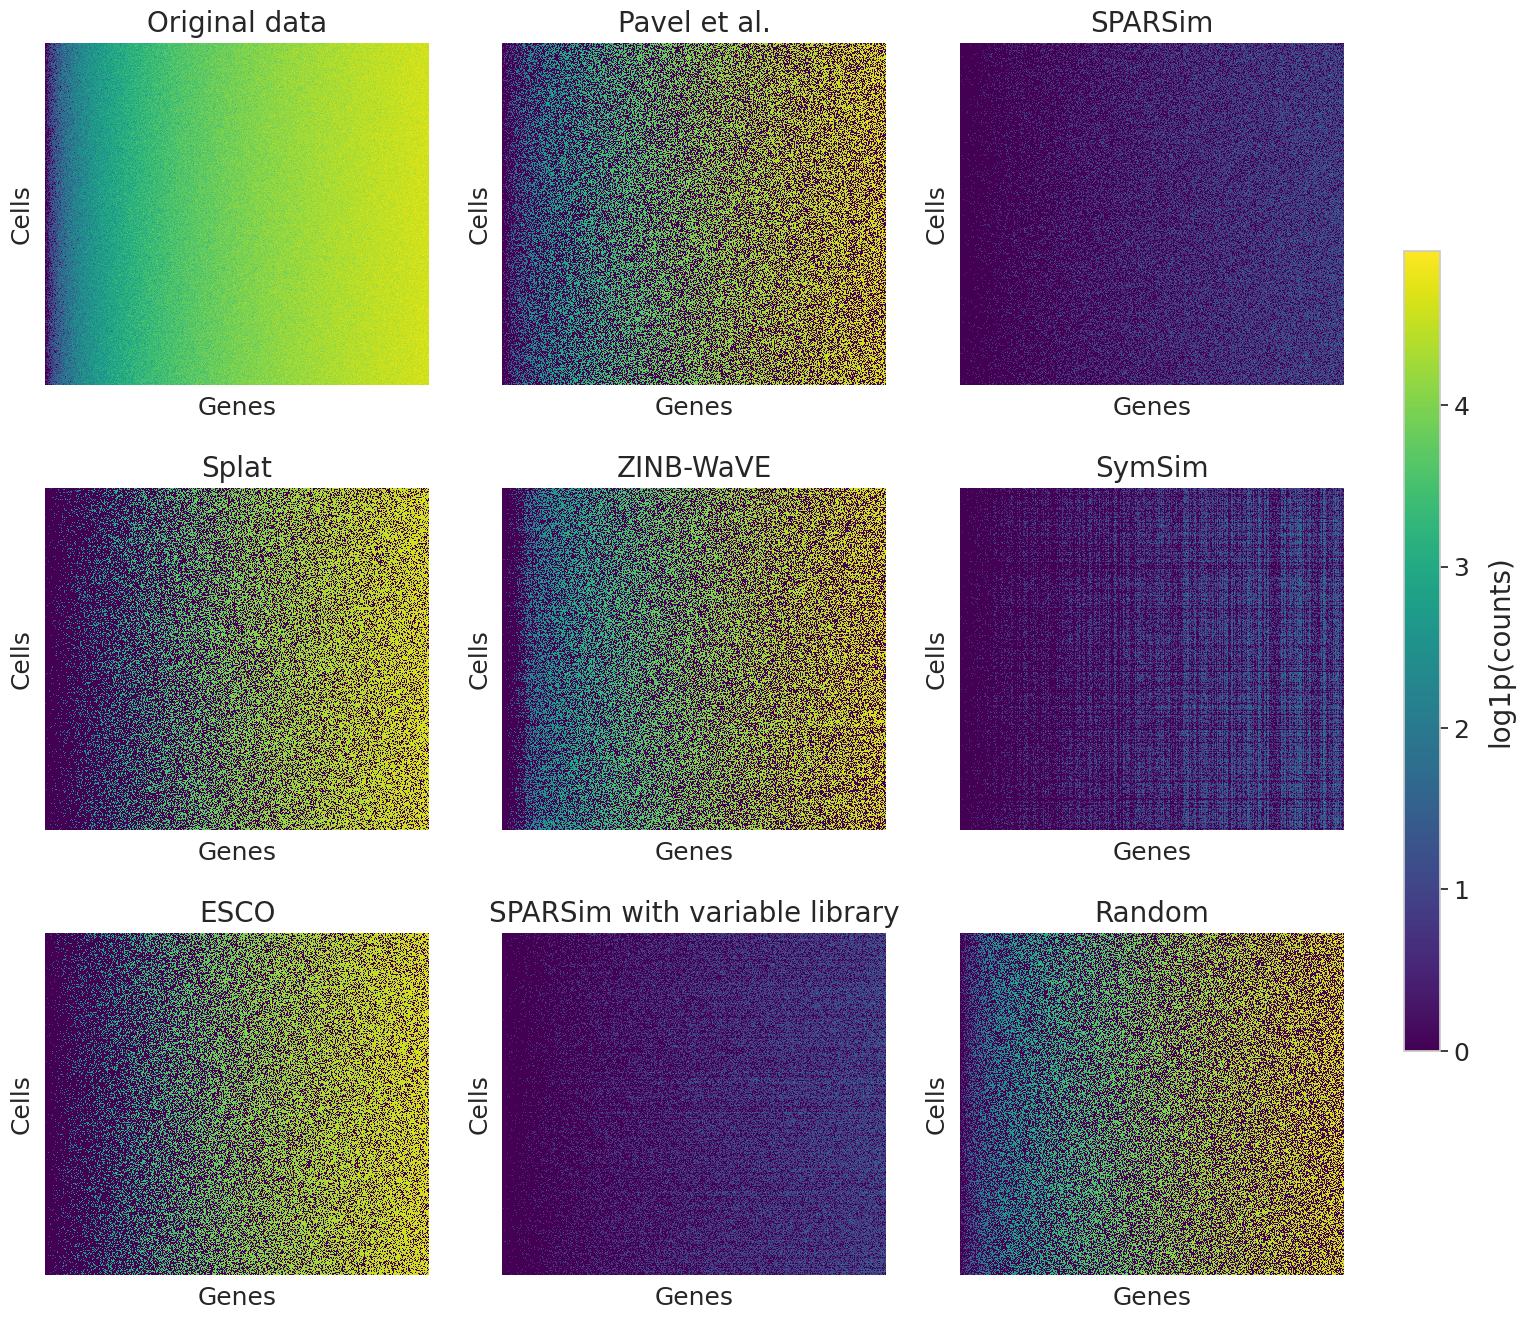

In [36]:
heatmaps = [
    ("Pavel et al.", counts_pavel),
    ("SPARSim", counts_sparsim),
    ("Splat", counts_splat),
    ("ZINB-WaVE", counts_zinbwave),
    ("SymSim", counts_symsim),
    ("ESCO", counts_esco),
    ("SPARSim with variable library", counts_sparsimvarlib),
    ("Random", counts_random),
]

# Original data first, followed by all methods
all_data = [
    ("Original data", adata.X.toarray()),
    *heatmaps
]

# Log-transform all matrices
log_counts = {
    name: np.log1p(matrix)
    for name, matrix in all_data
}

# Common color scale for every plot
vmin = min(matrix.min() for matrix in log_counts.values())
vmax = max(matrix.max() for matrix in log_counts.values())

fig = plt.figure(figsize=(18, 16))

gs = fig.add_gridspec(
    nrows=3,
    ncols=4,
    width_ratios=[1, 1, 1, 0.06],
    wspace=0.25,
    hspace=0.3
)

axes = [
    fig.add_subplot(gs[row, col])
    for row in range(3)
    for col in range(3)
]

cbar_ax = fig.add_axes([
    0.88,  # left
    0.25,  # bottom
    0.02,  # width
    0.50   # height
])

for i, (name, matrix) in enumerate(log_counts.items()):
    ax = axes[i]

    sns.heatmap(
        matrix,
        ax=ax,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        xticklabels=False,
        yticklabels=False
    )

    ax.set_title(name, fontsize=20, pad=8)
    ax.set_xlabel("Genes", fontsize=18, labelpad=8)
    ax.set_ylabel("Cells", fontsize=18, labelpad=8)

# Shared colorbar
norm = Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap="viridis")
sm.set_array([])

cbar = fig.colorbar(
    sm,
    cax=cbar_ax
)
cbar.set_label(
    "log1p(counts)",
    fontsize=20,
    labelpad=12
)
cbar.ax.tick_params(labelsize=18)

plt.savefig(
    "../outputs/Methods_Comparison/50p/"
    "heatmap_comparison_dropout_methods.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()